# Currency-Hedged ETF Carry — a quantitative teardown 🔬
### The carry decomposition · β ≈ 1 hedge regressions · HAC t's on the same-basket pair · rolling pass-through vs the policy differential · era splits · borrow-and-cost math · a planted-carry synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Unhedged_better_at_zero_carry%3F: Busted](https://img.shields.io/badge/Unhedged_better_at_zero_carry%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is covered-interest-parity arithmetic wearing an ETF wrapper; the job is to test whether live, fee-charging share classes deliver it, and to keep the carry leg cleanly separated from the FX leg and from basket mismatch.

> ⚠️ **Data note.** yfinance **total-return** closes; foreign short rates are hardcoded policy-rate step tables (BOJ call rate, ECB deposit rate — ±~15 bp vs 3M interbank). DXJ starts 2010-04 and HEDJ 2012-02 (both ran *unhedged* mandates before those dates; on the tape DXJ's hedge β is −0.15 pre-2010-04). Numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `866b58311fd5`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from currency_hedged_etf_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PANEL = data.monthly_panel(PRICES, asof=data.AS_OF)
else:
    PRICES = PANEL = None
# DXJ ran an UNHEDGED dividend mandate before 2010-04-01; HEDJ an unhedged one before Jan-2012.
PAIR_START = {"DXJ/EWJ": "2010-04-01", "HEDJ/VGK": "2012-02-01"}
HIGH = "2022-07-01"
print("real tape cached:", HAVE_REAL, "| months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '866b58311fd5', 'full': {'DXJ/EWJ': {'n': 195, 'start': '2010-04', 'beta': 1.05, 't_beta': 26.8, 'r2': 0.779, 'carry_bps': 21.08, 'carry_ann': 2.53, 't': 2.24, 'rate': 1.44, 'alpha_bps': 19.85, 't_alpha': 2.12, 'diff_bps': 45.99, 'fx_bps': -24.91}, 'HEWJ/EWJ': {'n': 148, 'start': '2014-03', 'beta': 0.971, 't_beta': 28.4, 'r2': 0.868, 'carry_bps': 19.92, 'carry_ann': 2.39, 't': 4.54, 'rate': 1.89, 'alpha_bps': 20.72, 't_alpha': 4.41, 'diff_bps': 47.72, 'fx_bps': -27.8}, 'HEDJ/VGK': {'n': 173, 'start': '2012-02', 'beta': 0.979, 't_beta': 17.4, 'r2': 0.68, 'carry_bps': 8.19, 'carry_ann': 0.98, 't': 0.84, 'rate': 1.11, 'alpha_bps': 8.32, 't_alpha': 0.86, 'diff_bps': 14.06, 'fx_bps': -5.87}}, 'high': {'DXJ/EWJ': {'carry_ann': 8.05, 't': 4.75, 'rate': 4.2, 'beta': 1.047, 'r2': 0.805}, 'HEWJ/EWJ': {'carry_ann': 4.83, 't': 6.01, 'rate': 4.2, 'beta': 0.98, 'r2': 0.879}, 'HEDJ/VGK': {'carry_ann': 2.63, 't': 0.9, 'rate': 1.71, 'beta': 0.941, 'r2': 0.621}}, 'zirp': {'diff_bps': 28.32, 't_diff': 0.82, 'fx_bps': -33.8, 'carry_ann': -0.66, 't_carry': -0.49, 'rate': 0.01, 'n': 69}, 'roll': {'DXJ/EWJ': (0.621, 1.83), 'HEWJ/EWJ': (0.851, 0.984), 'HEDJ/VGK': (0.227, 1.066)}, 'lags': [(3, 4.07, 4.51), (6, 4.54, 6.01), (12, 4.15, 7.67)], 'spread': {'DXJ/EWJ': (11.05, 2.74, 7.35, 4.34), 'HEWJ/EWJ': (7.84, 2.19, 4.13, 5.14), 'HEDJ/VGK': (-0.57, -0.17, 1.93, 0.66)}, 'charge_ann': 0.7, 'switch': {'DXJ/EWJ': (10.62, 13.34, 7.82, 3, 195), 'HEWJ/EWJ': (11.87, 14.21, 8.48, 3, 148), 'HEDJ/VGK': (9.02, 11.26, 9.57, 5, 173)}, 'syn': [(0.0, 0.152, 0.37), (5.0, 5.152, 12.68)], 'ers': {'DXJ': 0.48, 'EWJ': 0.5, 'HEWJ': 0.5, 'HEDJ': 0.58, 'VGK': 0.09}}


real tape cached: True | months: 258


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Same-basket pair (HEWJ = EWJ + forwards): β = 0.971 (t = 28.4), R² = 0.87; carry **+2.39%/yr at HAC t = +4.54** full-sample, **+4.83%/yr at t = +6.01** in 2022+; rolling pass-through corr +0.85, slope 0.98. EUR pair named as the split (t = +0.84 through basket noise). |
| **Tradability** | `INVESTABLE` | HEWJ ER = EWJ ER (0.50%); fx-stripped isolation trade nets **+4.13%/yr (t = +5.14)** after 0.70%/yr borrow+costs in 2022+; switch rule = 3 trades in 148 months. |
| **Unhedged better at zero carry?** | `BUSTED` | 2010–2015 (gap +0.01%/yr): carry -0.66%/yr (t = -0.49) — nothing to pocket — yet hedged won +28 bps/mo, all yen. |

> 💡 In plain words: the wrapper really is a full short of the currency plus the rate gap, delivered into a share class with the same fee. The gap is observable and moving — you harvest what exists, no more.

## 1 · The claim, steelmanned

Let $r^{loc}_t$ be the local equity return, $s_t$ the USD return of the foreign currency, $c_t$ the one-month forward premium. CIP: $c_t \approx r^{US}_t - r^{for}_t$ (per month, annualized in what follows). Then (log-approx):

$$r^{unhedged}_t \approx r^{loc}_t + s_t, \qquad r^{hedged}_t \approx r^{loc}_t + c_t$$

$$\Rightarrow\; \underbrace{(r^{hedged}_t - r^{unhedged}_t)}_{\text{diff}} = c_t - s_t\;\Rightarrow\; \widehat{c}_t := \text{diff}_t + s_t.$$

- **H₁ (mechanics).** Regressing diff on $-s_t$: β ≈ 1 (the wrapper is a full hedge), with α = the mean carry (+ basket alpha where baskets differ).
- **H₂ (the carry is the rate gap).** $\overline{\widehat{c}}$ matches the observable policy differential, tracks it over time (rolling corr/slope), and clears **HAC t ≥ 2** when the gap is fat (2022+).
- **H₃ (myth-check).** At a zero gap (2010–2015) $\widehat{c} \approx 0$ and any hedged-vs-unhedged difference is pure FX.

Basket mismatch (DXJ, HEDJ) contaminates α with basket alpha — which is why **HEWJ/EWJ (same basket) is the identification**.

## 2 · So what? — what rides on each answer

If H₁–H₂ hold, share-class choice is a **priced decision**: holding unhedged EWJ through 2022–2026 cost ~5%/yr of expected return relative to HEWJ, compensated only by long-yen exposure. If H₃ holds, the popular 2013-era claim "hedged Japan is just better" was a currency bet masquerading as engineering. Inference is **Newey-West HAC** throughout — hedge rolls and overlapping forwards leave serial correlation in monthly differentials — with lag sensitivity reported (3/6/12).

## 3 · How we'd know — the protocol

- **Pairs.** DXJ/EWJ (2010-04+, DXJ's hedged-mandate start), HEWJ/EWJ (2014-03+, same basket), HEDJ/VGK (2012-02+, post-mandate-switch). Total-return monthly closes, as-of 2026-06-30 (partial month dropped).
- **FX.** `JPY=X` (inverted: the yen's USD return) and `EURUSD=X`.
- **Rates.** `^IRX` monthly (US); BOJ/ECB policy step tables (hardcoded, sourced).
- **Estimator.** $\widehat{c}_t = \text{diff}_t + s_t$; HAC mean-t (6 lags); HAC OLS of diff on $-s_t$.
- **Eras.** Full sample · high-differential (2022-07→2026-06) · zero-carry (2010-04→2015-12, DXJ's hedged-mandate era only).
- **Costs.** Isolation spread: 50 bps/yr borrow on the short leg + 5 bps one-way × ~2 rebalances/yr. Switch rule: prior month-end differential > 1%/yr (**one-month lag, documented — the signal is a public policy rate**), 2 × 5 bps per switch.
- **Control.** `synthetic_world(carry_annual)` plants a tunable carry; the zero-carry null must not fire.

## 4 · The teardown

### 4a · The hedge regression — β ≈ 1 on the clean pair

diff$_t$ = α + β·(−$s_t$) + ε$_t$, HAC standard errors. β ≈ 1 says the wrapper is a full currency short; α is the monthly carry (plus basket alpha for mismatched pairs).

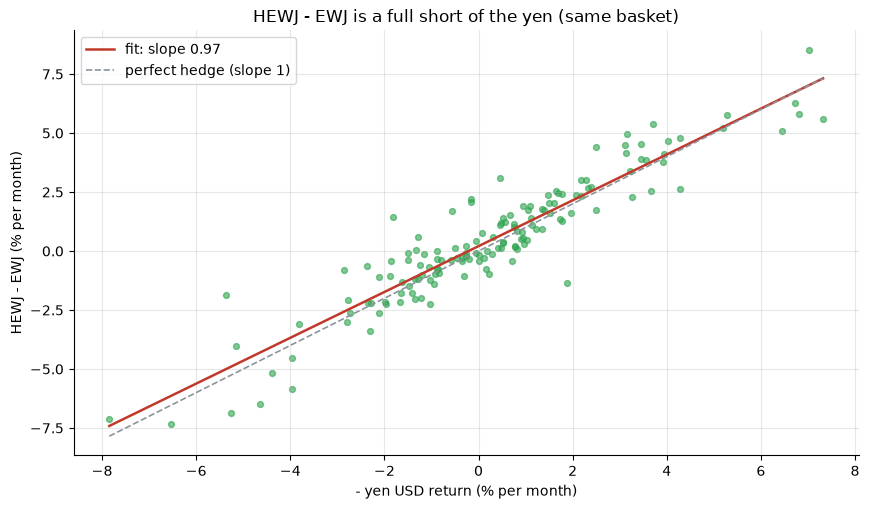

DXJ/EWJ    beta=+1.050 (t=+26.8)  R2=0.779  alpha=+19.85 bps/mo (t=+2.12)
HEWJ/EWJ   beta=+0.971 (t=+28.4)  R2=0.868  alpha=+20.72 bps/mo (t=+4.41)
HEDJ/VGK   beta=+0.979 (t=+17.4)  R2=0.680  alpha=+8.32 bps/mo (t=+0.86)


In [2]:
if HAVE_REAL:
    rows = []
    for p,(hgd,unh,ccy,_) in data.PAIRS.items():
        pf = st.pair_frame(PANEL, hgd, unh, ccy, start=PAIR_START.get(p))
        s = st.pair_stats(pf)
        rows.append((p, s['beta'], s['t_beta'], s['r2'], s['alpha_bps'], s['t_alpha']))
    pfc = st.pair_frame(PANEL, 'HEWJ', 'EWJ', 'JPY')
    xs, ys = -pfc['fx'].values*100, pfc['diff'].values*100
else:
    rows = [(p, R['full'][p]['beta'], R['full'][p]['t_beta'], R['full'][p]['r2'],
             R['full'][p]['alpha_bps'], R['full'][p]['t_alpha']) for p in R['full']]
    rng = np.random.default_rng(613)
    xs = rng.normal(0, 2.8, 148); ys = 0.97*xs + rng.normal(0.2, 0.5, 148)
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.scatter(xs, ys, s=18, alpha=.6, color=GREEN)
b = np.polyfit(xs, ys, 1)
grid = np.linspace(xs.min(), xs.max(), 50)
ax.plot(grid, np.polyval(b, grid), c=RED, lw=1.8, label=f'fit: slope {b[0]:.2f}')
ax.plot(grid, grid, c=GREY, ls='--', lw=1.2, label='perfect hedge (slope 1)')
ax.set_xlabel('- yen USD return (% per month)'); ax.set_ylabel('HEWJ - EWJ (% per month)')
ax.set_title('HEWJ - EWJ is a full short of the yen (same basket)'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<10s} beta={r[1]:+.3f} (t={r[2]:+.1f})  R2={r[3]:.3f}  alpha={r[4]:+.2f} bps/mo (t={r[5]:+.2f})')

> 💡 In plain words: on the same-basket pair the scatter sits on the 45° line — **β = 0.97, R² = 0.87** — and the intercept (**α = +20.7 bps/mo, HAC t = +4.41**) is the pocketed carry. DXJ's β of 1.05 (from its 2010-04 hedged-mandate start) confirms a full hedge there too, but its α mixes carry with exporter-basket alpha; HEDJ's β is 0.98 but its α is noise.

### 4b · The carry level and its tracking of the observable differential

Mean $\widehat{c}$ per window (HAC t) against the policy differential; then the 12-month rolling version.

pair        full carry      t    gap | 2022+ carry      t    gap
DXJ/EWJ         +2.53%  +2.24 +1.44% |      +8.05%  +4.75 +4.20%
HEWJ/EWJ        +2.39%  +4.54 +1.89% |      +4.83%  +6.01 +4.20%
HEDJ/VGK        +0.98%  +0.84 +1.11% |      +2.63%  +0.90 +1.71%


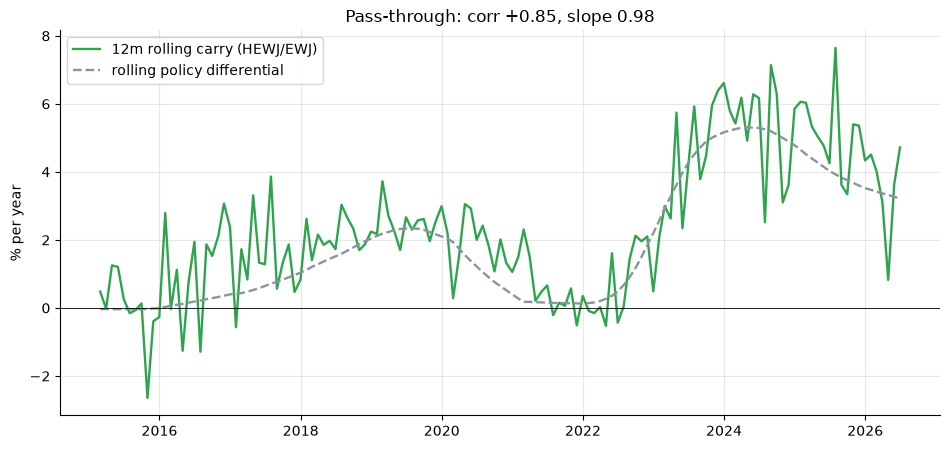

rolling corr = +0.851, pass-through slope = +0.984


In [3]:
if HAVE_REAL:
    tab = []
    for p,(hgd,unh,ccy,_) in data.PAIRS.items():
        pf_f = st.pair_frame(PANEL, hgd, unh, ccy, start=PAIR_START.get(p))
        pf_h = st.pair_frame(PANEL, hgd, unh, ccy, start=HIGH)
        sf, sh = st.pair_stats(pf_f), st.pair_stats(pf_h)
        tab.append((p, sf['carry_ann_pct'], sf['t_carry'], sf['rate_diff_ann_pct'],
                    sh['carry_ann_pct'], sh['t_carry'], sh['rate_diff_ann_pct']))
    r = st.rolling_carry_track(st.pair_frame(PANEL, 'HEWJ', 'EWJ', 'JPY'))
    roll_c, roll_d = r['roll_carry'], r['roll_diff']; corr, slope = r['corr'], r['slope']
else:
    tab = [(p, R['full'][p]['carry_ann'], R['full'][p]['t'], R['full'][p]['rate'],
            R['high'][p]['carry_ann'], R['high'][p]['t'], R['high'][p]['rate']) for p in R['full']]
    corr, slope = R['roll']['HEWJ/EWJ']; roll_c = roll_d = None
print(f"{'pair':<10s} {'full carry':>11s} {'t':>6s} {'gap':>6s} | {'2022+ carry':>11s} {'t':>6s} {'gap':>6s}")
for p,cf,tf,gf,ch,th,gh in tab:
    print(f'{p:<10s} {cf:>+10.2f}% {tf:>+6.2f} {gf:>+5.2f}% | {ch:>+10.2f}% {th:>+6.2f} {gh:>+5.2f}%')
if roll_c is not None:
    fig, ax = plt.subplots(figsize=(9.6, 4.6))
    ax.plot(roll_c, color=GREEN, lw=1.7, label='12m rolling carry (HEWJ/EWJ)')
    ax.plot(roll_d, color=GREY, ls='--', lw=1.7, label='rolling policy differential')
    ax.axhline(0, c='k', lw=.6); ax.set_ylabel('% per year')
    ax.set_title(f'Pass-through: corr {corr:+.2f}, slope {slope:.2f}'); ax.legend()
    plt.tight_layout(); plt.show()
print(f'rolling corr = {corr:+.3f}, pass-through slope = {slope:+.3f}')

> 💡 In plain words: the clean pair pockets **+2.39%/yr (t = +4.54)** over 12 years and **+4.83%/yr (t = +6.01)** when the gap was fat — vs observable gaps of +1.89% and +4.20%. The ~0.5%/yr excess over the *policy* gap has the right sign and size for the **negative JPY cross-currency basis** (Du–Tepper–Verdelhan): a USD hedger earns the differential *plus* the basis. The EUR pair passes the gap through at slope ≈ 1 but its mean is buried in basket noise — the honest split on the Signal axis.

### 4c · Lag sensitivity — the headline t is not a lag artefact

In [4]:
if HAVE_REAL:
    pf_c = st.pair_frame(PANEL, 'HEWJ', 'EWJ', 'JPY')
    pf_h = st.pair_frame(PANEL, 'HEWJ', 'EWJ', 'JPY', start=HIGH)
    rows = []
    for lg in (3, 6, 12):
        _, t1 = st.nw_mean_t(pf_c['carry_hat'].values, lg)
        _, t2 = st.nw_mean_t(pf_h['carry_hat'].values, lg)
        rows.append((lg, t1, t2))
else:
    rows = R['lags']
for lg, t1, t2 in rows: print(f'NW lags={lg:>2d}: full-sample t={t1:+.2f}   2022+ t={t2:+.2f}')

NW lags= 3: full-sample t=+4.07   2022+ t=+4.51
NW lags= 6: full-sample t=+4.54   2022+ t=+6.01
NW lags=12: full-sample t=+4.15   2022+ t=+7.67


> 💡 In plain words: whatever Newey-West window we pick (3, 6 or 12 months), the same-basket carry t stays between **+4.1 and +7.7** — far above the bar.

### 4d · Tradability — pocketing it after costs

Three ways in: (a) just hold the hedged class (ER gap ≈ 0 for Japan); (b) isolate the carry long-hedged/short-unhedged (pays 50 bps/yr borrow + 5 bps one-way × ~2 rebalances/yr — and note the raw spread is also short the currency); (c) the switch rule (prior-month differential > 1%/yr, one-month lag, 2 × 5 bps per switch).

In [5]:
if HAVE_REAL:
    sp_rows, sw_rows = [], []
    for p,(hgd,unh,ccy,_) in data.PAIRS.items():
        pf_h = st.pair_frame(PANEL, hgd, unh, ccy, start=HIGH)
        sp = st.spread_trade(pf_h)
        sp_rows.append((p, sp['net_diff_ann_pct'], sp['t_net_diff'], sp['net_carry_ann_pct'], sp['t_net_carry']))
        pf_f = st.pair_frame(PANEL, hgd, unh, ccy, start=PAIR_START.get(p))
        sw = st.switch_strategy(pf_f, (PANEL[hgd], PANEL[unh]))
        sw_rows.append((p, sw['strat_net_ann_pct'], sw['hedged_ann_pct'], sw['unhedged_ann_pct'], sw['switches'], sw['n']))
else:
    sp_rows = [(p, *R['spread'][p]) for p in R['spread']]
    sw_rows = [(p, *R['switch'][p]) for p in R['switch']]
print('isolation spread, 2022+, net of 0.70%/yr charges:')
for p, rn, tr, cn, tc in sp_rows:
    print(f'  {p:<10s} raw net {rn:+6.2f}%/yr (t={tr:+.2f})   fx-stripped carry net {cn:+6.2f}%/yr (t={tc:+.2f})')
print('switch rule (hold hedged when prior-month gap > 1%/yr):')
for p, sn, hn, un, k, n in sw_rows:
    print(f'  {p:<10s} net {sn:+6.2f}%/yr  vs hedged {hn:+6.2f}%  vs unhedged {un:+6.2f}%  ({k} switches / {n} mo)')

isolation spread, 2022+, net of 0.70%/yr charges:
  DXJ/EWJ    raw net +11.05%/yr (t=+2.74)   fx-stripped carry net  +7.35%/yr (t=+4.34)
  HEWJ/EWJ   raw net  +7.84%/yr (t=+2.19)   fx-stripped carry net  +4.13%/yr (t=+5.14)
  HEDJ/VGK   raw net  -0.57%/yr (t=-0.17)   fx-stripped carry net  +1.93%/yr (t=+0.66)
switch rule (hold hedged when prior-month gap > 1%/yr):
  DXJ/EWJ    net +10.62%/yr  vs hedged +13.34%  vs unhedged  +7.82%  (3 switches / 195 mo)
  HEWJ/EWJ   net +11.87%/yr  vs hedged +14.21%  vs unhedged  +8.48%  (3 switches / 148 mo)
  HEDJ/VGK   net  +9.02%/yr  vs hedged +11.26%  vs unhedged  +9.57%  (5 switches / 173 mo)


> 💡 In plain words: after borrow and costs the fx-stripped carry still nets **+4.1%/yr at t = +5.1** on the clean pair in the 2022+ era. The switch rule beats always-unhedged on both Japan pairs with 3–5 trades in 12–16 years; it trails always-hedged *ex post* only because the yen spent over a decade falling — a currency outcome, not a carry one. INVESTABLE, with the Europe ER-gap caveat (0.58% vs 0.09% eats half that pair's differential).

### 4e · Faithful-engine control — we know the truth here

Deterministic world: hedged = local + planted carry + tracking noise; unhedged = local + fx + tracking noise. The estimator must recover the knob; the zero-carry null must NOT fire. *(Machinery proof — never market evidence.)*

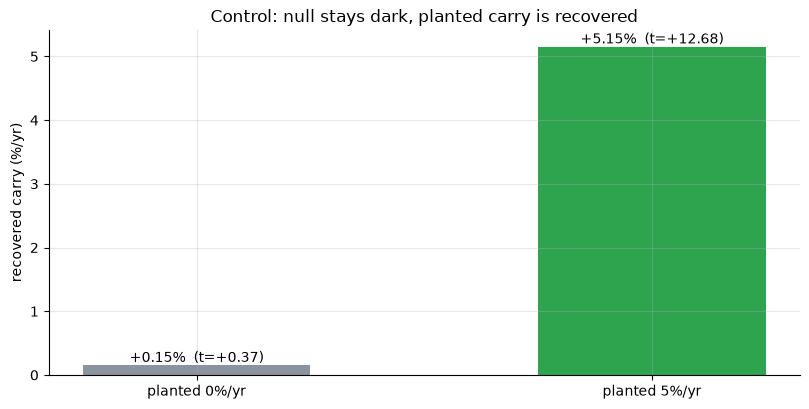

planted +0.0%/yr -> recovered +0.152%/yr (HAC t=+0.37)
planted +5.0%/yr -> recovered +5.152%/yr (HAC t=+12.68)


In [6]:
res = []
for carry in (0.0, 0.05):
    world = data.synthetic_world(carry_annual=carry, seed=613)
    pfx = pd.DataFrame({'diff': world['hedged'] - world['unhedged'], 'fx': world['fx'],
                        'rate_diff': world['rate_diff']}, index=world.index)
    pfx['carry_hat'] = pfx['diff'] + pfx['fx']
    s = st.pair_stats(pfx)
    res.append((carry*100, s['carry_ann_pct'], s['t_carry']))
fig, ax = plt.subplots(figsize=(8.2, 4.2))
labels = [f'planted {c:.0f}%/yr' for c,_,_ in res]
ax.bar(labels, [r[1] for r in res], color=[GREY, GREEN], width=.5)
for i,(c,v,t) in enumerate(res): ax.annotate(f'{v:+.2f}%  (t={t:+.2f})',(i,v),ha='center',va='bottom')
ax.set_ylabel('recovered carry (%/yr)'); ax.set_title('Control: null stays dark, planted carry is recovered')
plt.tight_layout(); plt.show()
for c,v,t in res: print(f'planted {c:+.1f}%/yr -> recovered {v:+.3f}%/yr (HAC t={t:+.2f})')

> 💡 In plain words: with **no** planted carry the estimator reads **+0.15%/yr (t = +0.37)** — it cannot manufacture carry from FX noise; a planted **+5%/yr** comes back as **+5.15%/yr**. The machinery is unbiased, so the real-tape t = 4.5–6.0 is the genuine article.

## 5 · The verdict

- **Signal `REAL`** — same-basket identification: β = 0.971 (t = 28.4), R² = 0.87; carry **+2.39%/yr, HAC t = +4.54** (full) and **+4.83%/yr, t = +6.01** (2022+), tracking the observable differential (corr +0.85, slope 0.98), lag-robust. DXJ corroborates; the EUR pair's thin differential can't clear the bar through basket noise — said out loud.
- **Tradability `INVESTABLE`** — zero ER gap on the Japan wrapper, public-policy-rate signal, 3–5 switches/decade, fx-stripped isolation nets +4.13%/yr (t = +5.14) after charges. Caveats: you pocket the *moving, observable* gap (already ~5.3 → ~3.3%/yr by mid-2026); Europe's 0.5%/yr ER gap.
- **Myth-check `BUSTED`** — at a zero differential (2010–2015) carry was -0.66%/yr (t = -0.49); the hedged class's big win then was the falling yen. Thin gap ⇒ the share-class choice is an FX bet.

## 6 · Going further

- **The basis bonus.** Measured carry ran ~0.5%/yr above the policy differential — consistent with the persistently negative JPY cross-currency basis (Du, Tepper & Verdelhan 2018). The wrapper collects it too.
- **Generalize.** The same identity prices every hedged share class (bond ETFs, UCITS hedged classes); the only inputs are the two short rates and the basis.
- **Dedup on the desk.** [364-fx-carry-trade](../../364-fx-carry-trade/README.md) asks whether *choosing* high-yield currencies is rewarded risk (crash-skewed, Weak). Here nothing is chosen: the wrapper transfers whatever gap exists — mechanics, not premium. Cousins: [611-mreit-carry](../../611-mreit-carry/README.md), [612-em-debt-carry](../../612-em-debt-carry/README.md).

*Frozen numbers: [`docs/results.md`](../docs/results.md); sources: [`docs/references.md`](../docs/references.md).*